In [6]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv
from langchain_groq import ChatGroq
import os

In [7]:
load_dotenv()

True

In [8]:
model = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0
)

In [9]:
class P_LLM_state(TypedDict):
    country: str
    states: str
    Major_lang: str
    Places: str

    summary: str

In [10]:
def state_of_place(state:P_LLM_state):
    ct = state['country']

    prompt = f'Please list all the states of the country - {ct}'

    response = model.invoke(prompt).content

    return {'states':response}

In [11]:
def Major_lang(state:P_LLM_state):
    ct = state['country']

    prompt = f'Please list all the langugages spoken in the country - {ct}'

    response = model.invoke(prompt).content

    return {'Major_lang':response}

In [12]:
def Places(state:P_LLM_state):
    ct = state['country']

    prompt = f'Please list any one famous place in the country - {ct}'

    response = model.invoke(prompt).content

    return {'Places':response}

In [13]:
def summary(state:P_LLM_state):
    ct = state['country']
    pl = state['Places']
    Major_lang = state['Major_lang']
    states = state['states']

    summary = f"""This {ct} have:\n
     Number of states- {states}\n
Number of Langugage spoken in the {ct} are - {Major_lang} 
And The country is popular for - {pl}"""
    
    return {'summary': summary}


In [14]:
graph = StateGraph(P_LLM_state)

graph.add_node('states',state_of_place)
graph.add_node('Major_lang', Major_lang)
graph.add_node('Places', Places)
graph.add_node('summary', summary)

graph.add_edge(START,'states')
graph.add_edge(START,'Major_lang')
graph.add_edge(START,'Places')

graph.add_edge('states','summary')
graph.add_edge('Major_lang','summary')
graph.add_edge('Places','summary')


graph.add_edge('summary',END)


workflow = graph.compile()

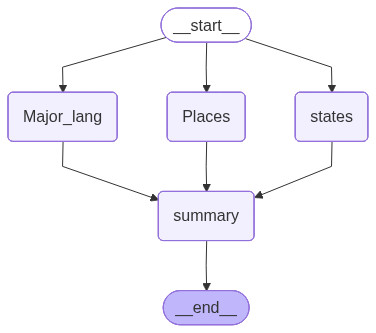

In [15]:
workflow

In [16]:
initial_state = {'country':'India'}

final_state = workflow.invoke(initial_state)


In [17]:
final_state

{'country': 'India',
 'states': "India is a vast and diverse country with 28 states and 8 union territories. Here's a list of all the states and union territories in India:\n\n**States:**\n\n1. Andhra Pradesh\n2. Arunachal Pradesh\n3. Assam\n4. Bihar\n5. Chhattisgarh\n6. Goa\n7. Gujarat\n8. Haryana\n9. Himachal Pradesh\n10. Jharkhand\n11. Karnataka\n12. Kerala\n13. Madhya Pradesh\n14. Maharashtra\n15. Manipur\n16. Meghalaya\n17. Mizoram\n18. Nagaland\n19. Odisha\n20. Punjab\n21. Rajasthan\n22. Sikkim\n23. Tamil Nadu\n24. Telangana\n25. Tripura\n26. Uttar Pradesh\n27. Uttarakhand\n28. West Bengal\n\n**Union Territories:**\n\n1. Andaman and Nicobar Islands\n2. Chandigarh\n3. Dadra and Nagar Haveli and Daman and Diu\n4. Delhi\n5. Jammu and Kashmir\n6. Ladakh\n7. Lakshadweep\n8. Puducherry\n\nNote: The union territory of Jammu and Kashmir was reorganized into two separate union territories, Jammu and Kashmir, and Ladakh, in August 2019.",
 'Major_lang': "India is a linguistically diverse c